In [13]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.preprocessing import (
    StandardScaler,
    LabelEncoder
)

from sklearn.metrics import (
    mean_absolute_error,
    r2_score
)

from sklearn.linear_model import LinearRegression

In [2]:
from google.colab import files

uploaded = files.upload()

Saving tesla_deliveries_dataset_2015_2025.csv to tesla_deliveries_dataset_2015_2025.csv


In [4]:
import pandas as pd

df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [5]:
df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


,0
Year,0
Month,0
Region,0
Model,0
Estimated_Deliveries,0
Production_Units,0
Avg_Price_USD,0
Battery_Capacity_kWh,0
Range_km,0
CO2_Saved_tons,0


In [6]:
df.drop_duplicates(inplace=True)

df.fillna(method='ffill', inplace=True)

/tmp/ipykernel_6343/67968268.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [8]:
plt.figure(figsize=(10,6))

plt.show()

<Figure size 1000x600 with 0 Axes>

In [14]:
print(df.columns)

Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')


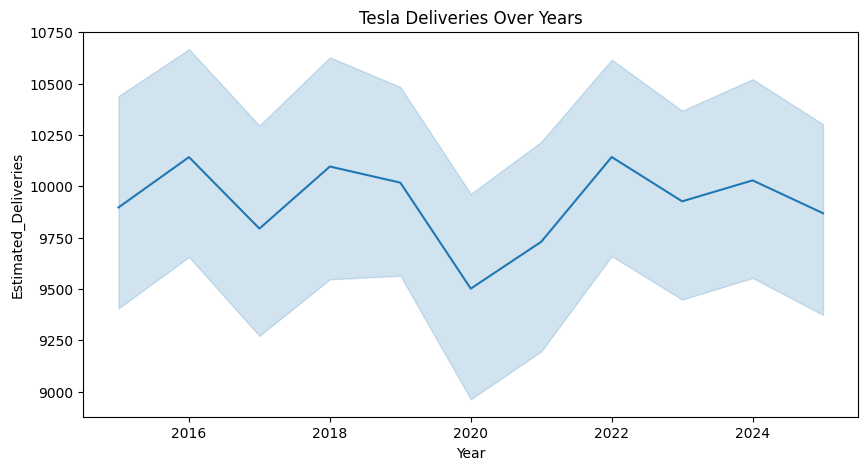

In [15]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=df,
    x="Year",
    y="Estimated_Deliveries"
)

plt.title("Tesla Deliveries Over Years")

plt.show()

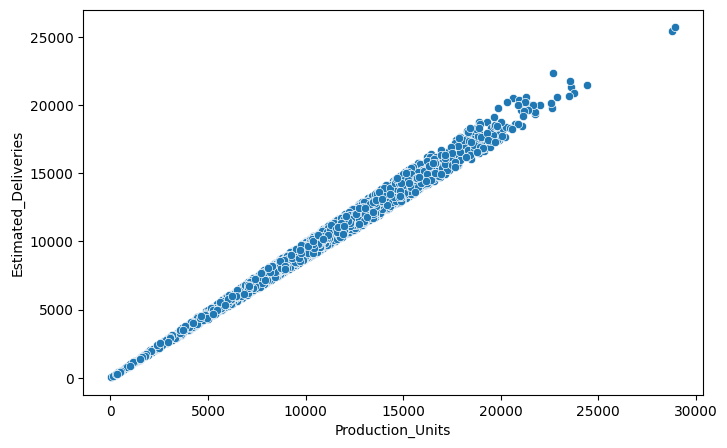

In [16]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Production_Units",
    y="Estimated_Deliveries"
)

plt.show()

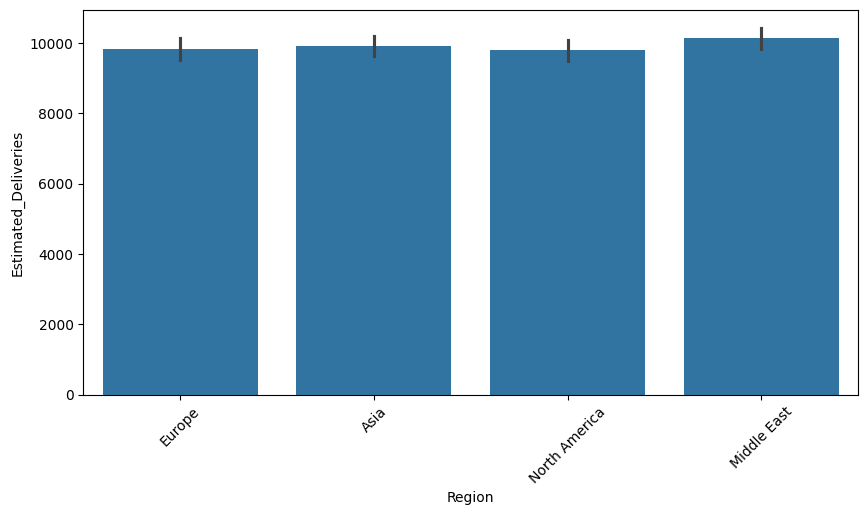

In [17]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x="Region",
    y="Estimated_Deliveries"
)

plt.xticks(rotation=45)

plt.show()

In [18]:
df["Efficiency"] = (
    df["Estimated_Deliveries"] /
    df["Production_Units"]
)

In [19]:
df["Revenue"] = (
    df["Estimated_Deliveries"] *
    df["Avg_Price_USD"]
)

In [20]:
df["Lag_1"] = (
    df["Estimated_Deliveries"]
    .shift(1)
)

In [21]:
df["Rolling_Mean"] = (
    df["Estimated_Deliveries"]
    .rolling(3)
    .mean()
)

In [22]:
df.dropna(inplace=True)

In [23]:
le_region = LabelEncoder()
le_model = LabelEncoder()
le_source = LabelEncoder()

df["Region"] = le_region.fit_transform(
    df["Region"]
)

df["Model"] = le_model.fit_transform(
    df["Model"]
)

df["Source_Type"] = le_source.fit_transform(
    df["Source_Type"]
)

In [24]:
X = df.drop(
    "Estimated_Deliveries",
    axis=1
)

y = df["Estimated_Deliveries"]

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [26]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [27]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [28]:
print("Linear Regression Results")

print(
    "MAE:",
    mean_absolute_error(y_test, lr_pred)
)

print(
    "R2 Score:",
    r2_score(y_test, lr_pred)
)

Linear Regression Results
MAE: 103.79558623226478
R2 Score: 0.9985880030336657


In [31]:
params = {
    "n_estimators":[100,200],
    "max_depth":[5,10]
}

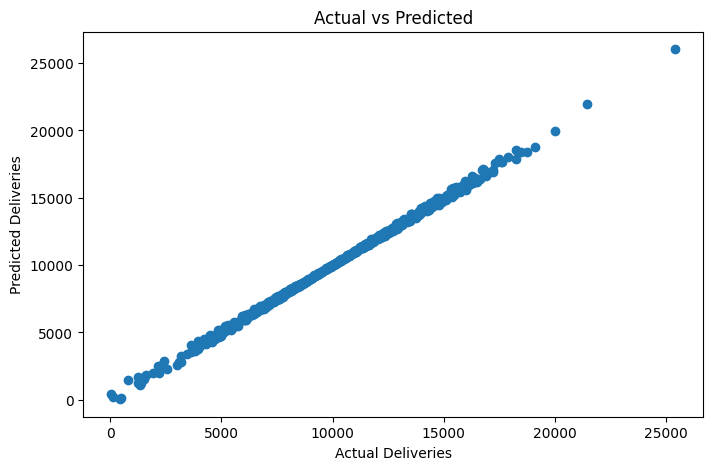

In [34]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, lr_pred)

plt.xlabel("Actual Deliveries")

plt.ylabel("Predicted Deliveries")

plt.title("Actual vs Predicted")

plt.show()

In [35]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    lr,
    X_train,
    y_train,
    cv=5
)

print(scores.mean())

0.9984154664940335
